In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from AttackInfo import Sensors, Actuators

In [2]:
df_normal = pd.read_parquet('../../Dataset/SWaT_Dataset_Normal_v1.parquet')
df_attack  = pd.read_parquet('../../Dataset/SWaT_Dataset_Attack_v1.parquet')

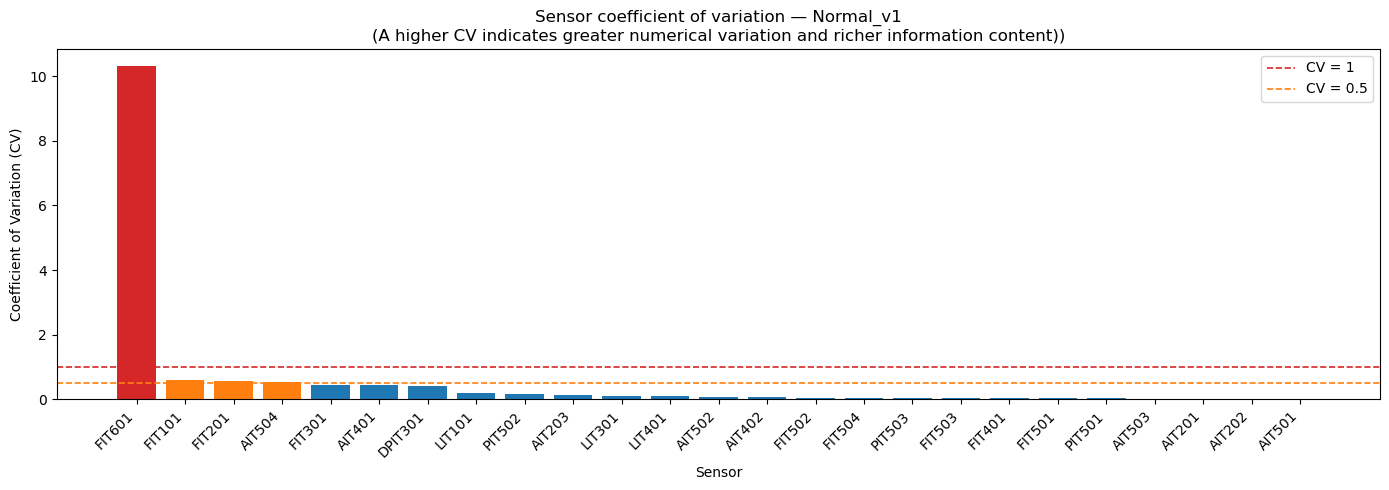

CV > 1 (高變異) 的感測器： ['FIT601']
CV < 0.1 (低變異) 的感測器： ['LIT401', 'AIT502', 'AIT402', 'FIT502', 'FIT504', 'PIT503', 'FIT503', 'FIT401', 'FIT501', 'PIT501', 'AIT503', 'AIT201', 'AIT202', 'AIT501']


In [3]:
# 8.1 感測器變異係數（CV = std/mean），識別資訊量豐富的特徵
sensor_cv = df_normal[Sensors].std() / df_normal[Sensors].mean().abs()
sensor_cv = sensor_cv.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(sensor_cv.index, sensor_cv.values,
              color=['#d62728' if v > 1 else '#ff7f0e' if v > 0.5 else '#1f77b4'
                     for v in sensor_cv.values])
ax.axhline(1.0, color='#d62728', ls='--', lw=1.2, label='CV = 1')
ax.axhline(0.5, color='#ff7f0e', ls='--', lw=1.2, label='CV = 0.5')
ax.set_xlabel('Sensor')
ax.set_ylabel('Coefficient of Variation (CV)')
ax.set_title('Sensor coefficient of variation — Normal_v1\n(A higher CV indicates greater numerical variation and richer information content))')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("CV > 1 (高變異) 的感測器：", sensor_cv[sensor_cv > 1].index.tolist())
print("CV < 0.1 (低變異) 的感測器：", sensor_cv[sensor_cv < 0.1].index.tolist())

In [4]:
# 8.2 致動器狀態頻率分析（Normal vs Attack）
act_cols = [c for c in Actuators if c in df_attack.columns]
act_normal_freq = df_normal[act_cols].apply(lambda c: c.value_counts(normalize=True))
act_attack_freq = df_attack[df_attack['Label']==1][act_cols].apply(lambda c: c.value_counts(normalize=True))

# 找出攻擊期間狀態頻率變化最大的致動器
freq_diff = {}
for col in act_cols:
    n_mode = df_normal[col].mode()[0]
    a_freq = (df_attack[df_attack['Label']==1][col] == n_mode).mean()
    n_freq = (df_normal[col] == n_mode).mean()
    freq_diff[col] = abs(a_freq - n_freq)

freq_diff_s = pd.Series(freq_diff).sort_values(ascending=False)
print("致動器主要狀態頻率變化（Normal → Attack，差距最大前 10）:")
for col, diff in freq_diff_s.head(15).items():
    n_f = (df_normal[col] == df_normal[col].mode()[0]).mean()
    a_f = (df_attack[df_attack['Label']==1][col] == df_normal[col].mode()[0]).mean()
    print(f"  {col:8s}: Normal={n_f:.3f}, Attack={a_f:.3f}, Δ={diff:.3f}")

致動器主要狀態頻率變化（Normal → Attack，差距最大前 10）:
  UV401   : Normal=0.997, Attack=0.383, Δ=0.614
  P501    : Normal=0.997, Attack=0.383, Δ=0.614
  MV304   : Normal=0.961, Attack=0.350, Δ=0.611
  P402    : Normal=0.997, Attack=0.407, Δ=0.590
  P302    : Normal=0.823, Attack=0.288, Δ=0.535
  MV302   : Normal=0.809, Attack=0.289, Δ=0.520
  P203    : Normal=0.747, Attack=0.257, Δ=0.490
  P101    : Normal=0.749, Attack=0.261, Δ=0.488
  MV201   : Normal=0.750, Attack=0.274, Δ=0.476
  MV101   : Normal=0.725, Attack=0.299, Δ=0.426
  P205    : Normal=0.662, Attack=0.260, Δ=0.401
  P102    : Normal=1.000, Attack=0.944, Δ=0.056
  P201    : Normal=1.000, Attack=0.986, Δ=0.014
  MV301   : Normal=0.988, Attack=0.981, Δ=0.006
  MV303   : Normal=0.971, Attack=0.975, Δ=0.005
